# CFD with Python — Curriculum Overview

## What This Curriculum Is

This is a self-contained, code-first guide to Computational Fluid Dynamics (CFD). You will start with
the question *"what is a fluid?"* and finish writing your own turbulent flow solver. Every concept
is paired with working Python code so the math never floats in the abstract.

---

## The Learning Path

```
[Module 01] Foundations — What CFD is, Python tools, conservation laws, finite differences
      ↓
[Module 02] Core CFD Methods — 2D grids, Finite Volume, Navier-Stokes, SIMPLE, cavity flow
      ↓
[Module 03] Advanced Topics — Turbulence, higher-order schemes, compressible flow, PINNs
      ↓
[Module 04] Projects — End-to-end engineering simulations
```

---

## Module Summary

| Module | Time | Key Skills |
|--------|------|------------|
| 01 Foundations | 6–10 hours | Conservation laws, finite differences, 1D solvers |
| 02 Core Methods | 8–12 hours | FVM, Navier-Stokes, SIMPLE, lid-driven cavity |
| 03 Advanced | 10–16 hours | Turbulence models, compressible flow, PINNs |
| 04 Projects | 12–20 hours | Real engineering simulations end-to-end |

**Total**: ~36–58 hours of focused learning.

---

## How CFD Works — The 60-Second Version

You want to simulate air flow over a car. The governing physics is the **Navier-Stokes equations** —
a set of PDEs that describe how velocity $\mathbf{u}$, pressure $p$, and density $\rho$ evolve in space
and time. Solving them analytically is impossible for any realistic geometry.

CFD converts the continuous PDEs into a discrete system a computer can solve:

1. **Divide** the fluid domain into thousands of small cells (the mesh).
2. **Discretize** the PDEs — replace derivatives with algebraic differences on the mesh.
3. **Assemble** a large system of equations $A\mathbf{x} = \mathbf{b}$.
4. **Solve** iteratively to get velocity and pressure at every cell.
5. **Post-process** — visualize streamlines, pressure contours, drag force.

This is exactly what ANSYS Fluent, OpenFOAM, and Star-CCM+ do under the hood.

---

## Prerequisites

- **Python**: Know how to write loops and functions. NumPy arrays are a bonus.
- **Calculus**: Partial derivatives, the chain rule, integration.
- **Linear algebra**: Matrix multiplication, solving $Ax = b$.
- **Physics**: Newton's second law, pressure, density. No fluid mechanics background needed.

---

## Guiding Principles

1. **Build from scratch first, use libraries second.** You'll write a full Navier-Stokes solver
   in NumPy before touching any CFD library. This ensures you understand what the solver does for you.
2. **Always verify against analytical solutions.** Every solver you write will be checked against
   a known exact answer before you trust it.
3. **Visualize everything.** Plots reveal bugs that print statements miss.
4. **One equation, one analogy, one code cell.** If you can't explain it in plain English first,
   the math hasn't been understood yet.


## Where Each Module Fits in the CFD Pipeline

```
Physical problem (wing, pipe, engine)
      │
      ▼
Governing equations (N-S)  ← Module 02 (lesson 03)
      │
      ▼
Discretization (FDM/FVM)   ← Module 01 (lessons 05-08), Module 02 (lesson 02)
      │
      ▼
Mesh generation             ← Module 03 (lesson 03)
      │
      ▼
Boundary conditions         ← Module 02 (lesson 08)
      │
      ▼
Linear system solver        ← Module 02 (lessons 04-06)
      │
      ▼
Turbulence modeling         ← Module 03 (lessons 01-02)
      │
      ▼
Post-processing             ← Throughout
```


In [1]:
# Check your environment — run this before starting
import importlib
import sys

required = ['numpy', 'matplotlib', 'scipy']
optional = ['numba', 'meshio', 'torch']

print(f"Python {sys.version}\n")

print("Required packages:")
for pkg in required:
    try:
        m = importlib.import_module(pkg)
        print(f"  ✓ {pkg} {getattr(m, '__version__', 'ok')}")
    except ImportError:
        print(f"  ✗ {pkg} — run: pip install {pkg}")

print("\nOptional packages (needed for later modules):")
for pkg in optional:
    try:
        m = importlib.import_module(pkg)
        print(f"  ✓ {pkg} {getattr(m, '__version__', 'ok')}")
    except ImportError:
        print(f"  - {pkg} not installed (needed for Module 03+)")

Python 3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:14:06) [Clang 20.1.8 ]

Required packages:
  ✓ numpy 2.4.4
  ✓ matplotlib 3.10.9
  ✓ scipy 1.17.1

Optional packages (needed for later modules):
  - numba not installed (needed for Module 03+)
  - meshio not installed (needed for Module 03+)
  ✓ torch 2.11.0


## A Taste of What You'll Build

By the end of Module 02 you'll have a working lid-driven cavity solver. Here's a preview of the
kind of velocity field you'll be computing:


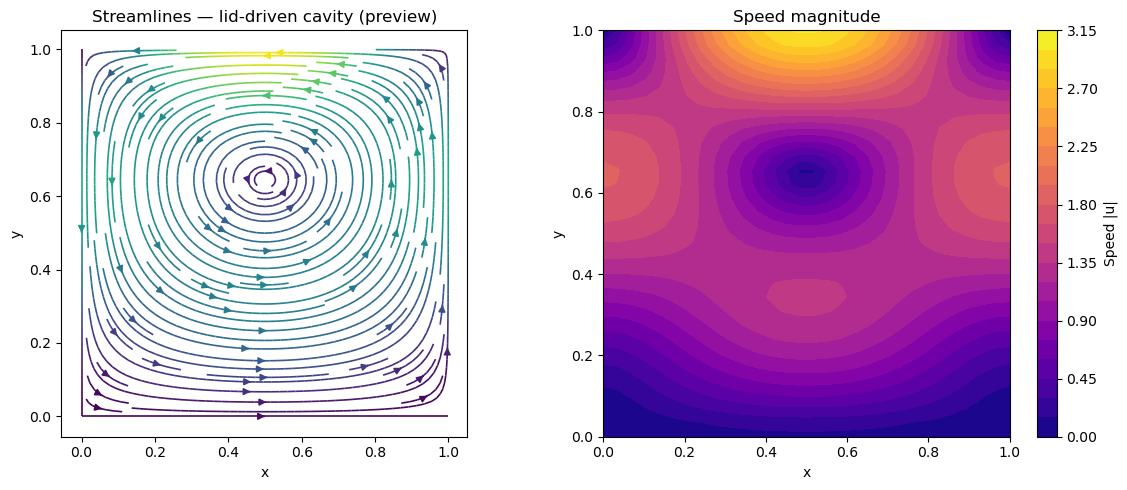

By Module 02 you'll compute this with a real Navier-Stokes solver!


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# A simplified analytic approximation to lid-driven cavity flow
# (not the real solver — that comes in Module 02, Lesson 06)
N = 30
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

# Approximate streamfunction: psi = sin(pi*x)*sin(pi*y) * y
psi = np.sin(np.pi * X) * np.sin(np.pi * Y) * Y

# Velocities from streamfunction: u = dpsi/dy, v = -dpsi/dx
dy = 1.0 / (N - 1)
dx = 1.0 / (N - 1)
U = np.gradient(psi, dy, axis=0)
V = -np.gradient(psi, dx, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Streamlines
axes[0].streamplot(X, Y, U, V, color=np.sqrt(U**2 + V**2),
                   cmap='viridis', linewidth=1.2, density=1.5)
axes[0].set_title('Streamlines — lid-driven cavity (preview)', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_aspect('equal')

# Speed contour
speed = np.sqrt(U**2 + V**2)
cf = axes[1].contourf(X, Y, speed, levels=20, cmap='plasma')
plt.colorbar(cf, ax=axes[1], label='Speed |u|')
axes[1].set_title('Speed magnitude', fontsize=12)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()
print("By Module 02 you'll compute this with a real Navier-Stokes solver!")